# Segmentação de Núcleos com FCN — Comparativo com e sem Data Augmentation

**Objetivo:** classificar cada pixel da imagem como *fundo* ou *núcleo* (segmentação binária), utilizando uma FCN (Fully Convolutional Network) baseada em ResNet-50, e comparar o efeito do **Data Augmentation** no resultado final.

Para cada um dos dois modelos (sem e com augmentation) este notebook registra:
- Função de perda utilizada;
- Otimizador;
- Taxa de aprendizado;
- Número de épocas;
- Tamanho do batch;
- Métricas obtidas no conjunto de teste: **acurácia de pixels**, **Dice** e **IoU**, calculadas em relação às **máscaras de referência**.

Ao final, os dois modelos são comparados lado a lado, tanto numericamente (tabela + gráficos) quanto visualmente (máscaras preditas sobrepostas às máscaras de referência).

> ⚠️ **Importante sobre a metodologia:** para que a comparação seja justa, os dois modelos são treinados e avaliados sobre **exatamente a mesma divisão treino/teste** (mesmas imagens). O *Data Augmentation* é aplicado **apenas no conjunto de treino** do modelo "com augmentation" — nunca no conjunto de teste, que permanece sempre com as imagens originais para ambos os modelos.


## 1. Configuração inicial (Drive, bibliotecas e reprodutibilidade)

In [11]:
# ===================== MONTAGEM DO GOOGLE DRIVE (COLAB) =====================
from google.colab import drive
drive.mount('/content/drive')

# ===================== CAMINHO RAIZ NO DRIVE =====================
# Estrutura esperada dentro de drive_root:
#   dataset/healthy/*.tif, dataset/severe/*.tif
#   reference_masks/healthy/*.png, reference_masks/severe/*.png
drive_root = '/content/drive/MyDrive/LIPAI/S19'

import os
import glob
import shutil
import random

import numpy as np
import cv2
from PIL import Image

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

import pandas as pd
import matplotlib.pyplot as plt

import random
import torchvision.transforms.functional as TF

from tqdm import tqdm

# ===================== REPRODUTIBILIDADE =====================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Usando device: cuda


## 2. Leitura dos Dados

A classe `SegmentationDatasetWithMasks` percorre as pastas `healthy` e `severe`, casando cada imagem `.tif` com sua respectiva máscara de referência `.png` (mesmo nome de arquivo). As imagens e máscaras são redimensionadas para 512x512 e a máscara é binarizada (0 = fundo, 1 = núcleo).

In [14]:
class SegmentationDatasetWithMasks(Dataset):

    def __init__(self,
                 dataset_root,
                 masks_root,
                 augment=False):

        self.augment = augment
        self.images = []
        self.masks = []

        for category in ["healthy", "severe"]:

            image_dir = os.path.join(dataset_root, category)
            mask_dir  = os.path.join(masks_root, category)

            if not os.path.exists(image_dir):
                continue

            for img_path in sorted(glob.glob(os.path.join(image_dir, "*.tif"))):

                mask_path = os.path.join(
                    mask_dir,
                    os.path.basename(img_path).replace(".tif", ".png")
                )

                if os.path.exists(mask_path):
                    self.images.append(img_path)
                    self.masks.append(mask_path)

    def __len__(self):
        return len(self.images)

    def filename(self, idx):
        return os.path.splitext(os.path.basename(self.images[idx]))[0]

    def __getitem__(self, idx):

        image = Image.open(self.images[idx]).convert("RGB")
        mask  = Image.open(self.masks[idx]).convert("L")

        image = image.resize((512,512), Image.BILINEAR)
        mask  = mask.resize((512,512), Image.NEAREST)

        if self.augment:

            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-30,30)

            image = TF.rotate(
                image,
                angle,
                interpolation=TF.InterpolationMode.BILINEAR
            )

            mask = TF.rotate(
                mask,
                angle,
                interpolation=TF.InterpolationMode.NEAREST
            )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225]
        )

        mask = np.array(mask)

        # funciona para qualquer máscara binária
        mask = (mask != 0).astype(np.int64)

        mask = torch.from_numpy(mask)

        return image, mask


# ===================== TRANSFORMAÇÕES =====================
# Sem augmentation: apenas conversão para tensor (usada no treino "sem augmentation" e SEMPRE no teste)
transform_base = transforms.Compose([
    transforms.ToTensor(),
])

# Com augmentation: usada apenas no treino do modelo "com augmentation"
transform_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
])

dataset_root = os.path.join(drive_root, 'dataset')
masks_root = os.path.join(drive_root, 'reference_masks')

# Duas "visões" do mesmo conjunto de arquivos: uma sem augmentation e outra com.
dataset_base = SegmentationDatasetWithMasks(dataset_root, masks_root, augment=False)
dataset_aug  = SegmentationDatasetWithMasks(dataset_root, masks_root, augment=True)

assert len(dataset_base) == len(dataset_aug) and len(dataset_base) > 0, \
    "Nenhuma máscara encontrada! Verifique os caminhos das pastas no Drive."

# ===================== DIVISÃO TREINO/TESTE (ÚNICA, COMPARTILHADA PELOS DOIS MODELOS) =====================
n_total = len(dataset_base)
indices = list(range(n_total))
random.Random(SEED).shuffle(indices)

train_size = int(0.8 * n_total)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

print(f"\nTotal de amostras: {n_total}")
print(f"Treino: {len(train_idx)}  |  Teste: {len(test_idx)}")



Total de amostras: 228
Treino: 182  |  Teste: 46


## 3. Hiperparâmetros

In [4]:
# Hiperparâmetros (iguais para os dois modelos, para isolar o efeito do augmentation)
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
BATCH_SIZE = 10
NUM_CLASSES = 2  # fundo e núcleo
LOSS_NAME = "CrossEntropyLoss"
OPTIMIZER_NAME = "Adam"
AUGMENTATIONS_DESC = "RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(30°)"

# DataLoaders — o conjunto de TESTE é sempre o mesmo (dataset_base), para os dois modelos
train_loader_no_aug = DataLoader(Subset(dataset_base, train_idx), batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug    = DataLoader(Subset(dataset_aug,  train_idx), batch_size=BATCH_SIZE, shuffle=True)
test_loader         = DataLoader(Subset(dataset_base, test_idx),  batch_size=BATCH_SIZE, shuffle=False)


## 4. Modelo (função reutilizável)

In [5]:
def build_model(num_classes, device):
    '''Cria uma FCN-ResNet50 pré-treinada e adapta a camada final para `num_classes`.'''
    model = fcn_resnet50(weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
    model.classifier[4] = nn.Conv2d(512, num_classes, kernel_size=1)
    model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    return model.to(device)


## 5. Métricas de comparação com a máscara de referência

- **Acurácia de pixels**: proporção de pixels classificados corretamente;
- **Dice (F1)**: `2 * interseção / (área_pred + área_ref)`;
- **IoU (Jaccard)**: `interseção / união`.

In [6]:
def calculate_pixel_accuracy(pred, target):
    return torch.mean((pred == target).float()).item()

def calculate_dice(pred, target):
    pred_flat = pred.flatten().float()
    target_flat = target.flatten().float()
    intersection = torch.sum(pred_flat * target_flat)
    union = torch.sum(pred_flat) + torch.sum(target_flat)
    if union == 0:
        return 1.0 if (pred_flat == target_flat).all() else 0.0
    return (2.0 * intersection / union).item()

def calculate_iou(pred, target):
    pred_flat = pred.flatten().float()
    target_flat = target.flatten().float()
    intersection = torch.sum(pred_flat * target_flat)
    union = torch.sum(pred_flat) + torch.sum(target_flat) - intersection
    if union == 0:
        return 1.0 if (pred_flat == target_flat).all() else 0.0
    return (intersection / union).item()


## 6. Funções genéricas de treinamento e avaliação

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc = "Training loop"):
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs['out'], masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    '''Avalia o modelo comparando as máscaras preditas com as máscaras de referência.'''
    model.eval()
    total_loss = 0
    total_pixel_acc = 0
    total_dice = 0
    total_iou = 0
    count = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, "Validation loop"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs['out'], masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs['out'], dim=1)

            for i in range(preds.shape[0]):
                total_pixel_acc += calculate_pixel_accuracy(preds[i], masks[i])
                total_dice += calculate_dice(preds[i], masks[i])
                total_iou += calculate_iou(preds[i], masks[i])
                count += 1

    return {
        'loss': total_loss / len(loader),
        'pixel_acc': total_pixel_acc / count if count else 0.0,
        'dice': total_dice / count if count else 0.0,
        'iou': total_iou / count if count else 0.0,
    }


def run_training(model, train_loader, test_loader, optimizer, criterion, device, num_epochs, label):
    history = {'train_loss': [], 'test_loss': [], 'pixel_acc': [], 'dice': [], 'iou': []}
    print("\n" + "=" * 60)
    print(f"TREINANDO FCN ResNet50 ({label})")
    print("=" * 60)

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        metrics = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(metrics['loss'])
        history['pixel_acc'].append(metrics['pixel_acc'])
        history['dice'].append(metrics['dice'])
        history['iou'].append(metrics['iou'])

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {train_loss:.4f} | Test Loss: {metrics['loss']:.4f} | "
                  f"Acc: {metrics['pixel_acc']:.4f} | Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f}")

    return history


def save_predicted_masks(model, loader, dataset, indices, output_dir, device):
    '''Gera e salva no Drive as máscaras preditas para o conjunto de teste.
    Os arquivos são salvos com o MESMO nome da imagem original, para permitir
    o pareamento direto entre modelos e com a máscara de referência.'''
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    saved = 0
    with torch.no_grad():
        idx_pointer = 0
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            predictions = torch.argmax(outputs['out'], dim=1).cpu().numpy()

            for i in range(predictions.shape[0]):
                original_idx = indices[idx_pointer]
                fname = dataset.filename(original_idx)
                mask_img = (predictions[i] * 255).astype(np.uint8)
                cv2.imwrite(os.path.join(output_dir, f'{fname}.png'), mask_img)
                idx_pointer += 1
                saved += 1

    print(f"✓ {saved} máscaras salvas em '{output_dir}'")


## 7. Treinamento — FCN **sem** Data Augmentation

In [15]:
model_no_aug = build_model(NUM_CLASSES, device)
criterion_no_aug = nn.CrossEntropyLoss()
optimizer_no_aug = torch.optim.Adam(model_no_aug.parameters(), lr=LEARNING_RATE)

history_no_aug = run_training(
    model_no_aug, train_loader_no_aug, test_loader,
    optimizer_no_aug, criterion_no_aug, device,
    NUM_EPOCHS, label="SEM DATA AUGMENTATION"
)

output_dir_no_aug = os.path.join(drive_root, 'fcn_masks', 'sem_augmentation')
save_predicted_masks(model_no_aug, test_loader, dataset_base, test_idx, output_dir_no_aug, device)



TREINANDO FCN ResNet50 (SEM DATA AUGMENTATION)


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]


Epoch  1/10 | Loss: 0.5097 | Test Loss: 2.6735 | Acc: 0.7451 | Dice: 0.1593 | IoU: 0.0923


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.22it/s]


Epoch  5/10 | Loss: 0.2277 | Test Loss: 0.2997 | Acc: 0.8662 | Dice: 0.7627 | IoU: 0.6214


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]


Epoch 10/10 | Loss: 0.1825 | Test Loss: 0.3364 | Acc: 0.8575 | Dice: 0.7175 | IoU: 0.5655
✓ 46 máscaras salvas em '/content/drive/MyDrive/LIPAI/S19/fcn_masks/sem_augmentation'


## 8. Treinamento — FCN **com** Data Augmentation

In [16]:
model_aug = build_model(NUM_CLASSES, device)
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LEARNING_RATE)

history_aug = run_training(
    model_aug, train_loader_aug, test_loader,
    optimizer_aug, criterion_aug, device,
    NUM_EPOCHS, label="COM DATA AUGMENTATION"
)

output_dir_aug = os.path.join(drive_root, 'fcn_masks', 'com_augmentation')
save_predicted_masks(model_aug, test_loader, dataset_base, test_idx, output_dir_aug, device)



TREINANDO FCN ResNet50 (COM DATA AUGMENTATION)


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.19it/s]


Epoch  1/10 | Loss: 0.4758 | Test Loss: 1.1161 | Acc: 0.7712 | Dice: 0.3083 | IoU: 0.2103


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.19it/s]


Epoch  5/10 | Loss: 0.2592 | Test Loss: 0.2986 | Acc: 0.8682 | Dice: 0.7349 | IoU: 0.5869


Validation loop: 100%|██████████| 5/5 [00:04<00:00,  1.22it/s]


Epoch 10/10 | Loss: 0.2470 | Test Loss: 0.2862 | Acc: 0.8737 | Dice: 0.7616 | IoU: 0.6227
✓ 46 máscaras salvas em '/content/drive/MyDrive/LIPAI/S19/fcn_masks/com_augmentation'


## 9. Comparativo entre os modelos (com x sem Data Augmentation)

### 9.1 Configuração de treinamento e métricas finais no conjunto de teste

In [17]:
summary_rows = [
    {
        'Modelo': 'Sem Augmentation',
        'Função de perda': LOSS_NAME,
        'Otimizador': OPTIMIZER_NAME,
        'Taxa de aprendizado': LEARNING_RATE,
        'Épocas': NUM_EPOCHS,
        'Batch size': BATCH_SIZE,
        'Augmentation': '-',
        'Acurácia de Pixels': history_no_aug['pixel_acc'][-1],
        'Dice': history_no_aug['dice'][-1],
        'IoU': history_no_aug['iou'][-1],
        'Loss (teste)': history_no_aug['test_loss'][-1],
    },
    {
        'Modelo': 'Com Augmentation',
        'Função de perda': LOSS_NAME,
        'Otimizador': OPTIMIZER_NAME,
        'Taxa de aprendizado': LEARNING_RATE,
        'Épocas': NUM_EPOCHS,
        'Batch size': BATCH_SIZE,
        'Augmentation': AUGMENTATIONS_DESC,
        'Acurácia de Pixels': history_aug['pixel_acc'][-1],
        'Dice': history_aug['dice'][-1],
        'IoU': history_aug['iou'][-1],
        'Loss (teste)': history_aug['test_loss'][-1],
    },
]

df_comparativo = pd.DataFrame(summary_rows)

# Linha de diferença (com - sem augmentation) para as métricas numéricas
delta = {
    'Modelo': 'Δ (com - sem)',
    'Função de perda': '', 'Otimizador': '', 'Taxa de aprendizado': '',
    'Épocas': '', 'Batch size': '', 'Augmentation': '',
    'Acurácia de Pixels': history_aug['pixel_acc'][-1] - history_no_aug['pixel_acc'][-1],
    'Dice': history_aug['dice'][-1] - history_no_aug['dice'][-1],
    'IoU': history_aug['iou'][-1] - history_no_aug['iou'][-1],
    'Loss (teste)': history_aug['test_loss'][-1] - history_no_aug['test_loss'][-1],
}
df_comparativo = pd.concat([df_comparativo, pd.DataFrame([delta])], ignore_index=True)

# Salva o comparativo no Drive
comparativo_dir = os.path.join(drive_root, 'fcn_masks')
os.makedirs(comparativo_dir, exist_ok=True)
df_comparativo.to_csv(os.path.join(comparativo_dir, 'comparativo_metricas.csv'), index=False)

df_comparativo


,Modelo,Função de perda,Otimizador,Taxa de aprendizado,Épocas,Batch size,Augmentation,Acurácia de Pixels,Dice,IoU,Loss (teste)
0,Sem Augmentation,CrossEntropyLoss,Adam,0.001,10,10,-,0.857538,0.717453,0.565450,0.336439
1,Com Augmentation,CrossEntropyLoss,Adam,0.001,10,10,"RandomHorizontalFlip, RandomVerticalFlip, Rand...",0.873695,0.761605,0.622711,0.286172
2,Δ (com - sem),,,,,,,0.016157,0.044152,0.057261,-0.050267


### 9.2 Evolução das métricas ao longo do treinamento

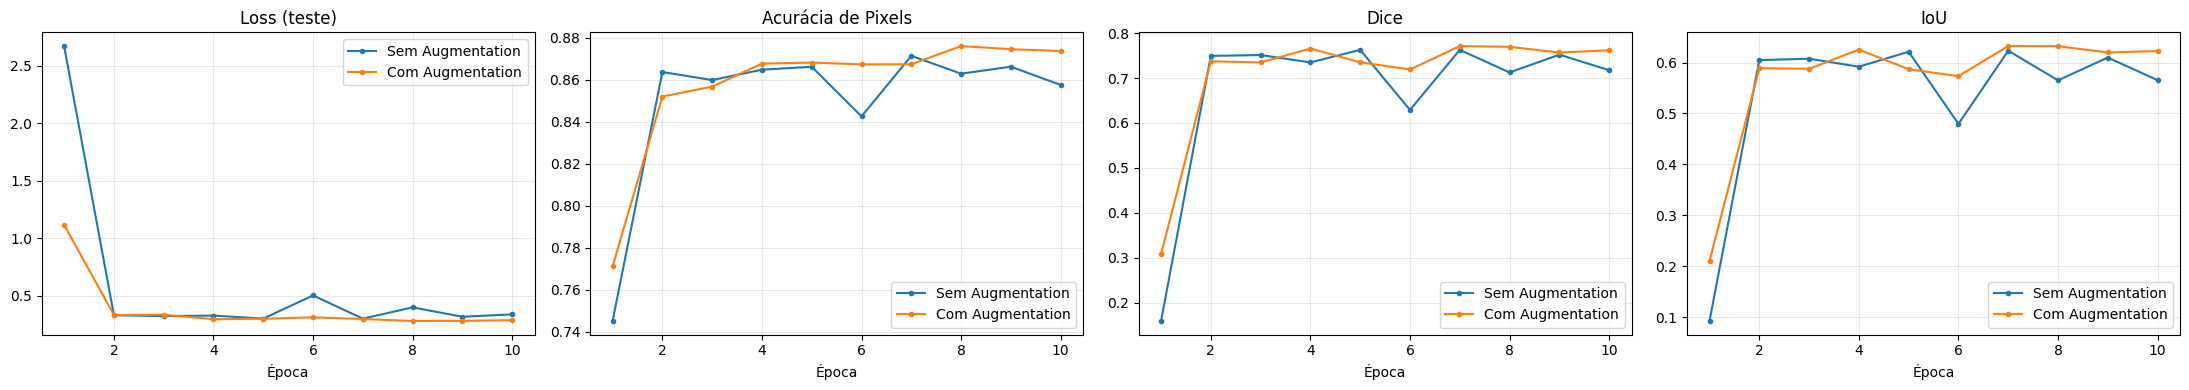

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

metric_plots = [
    ('test_loss', 'Loss (teste)'),
    ('pixel_acc', 'Acurácia de Pixels'),
    ('dice', 'Dice'),
    ('iou', 'IoU'),
]

for ax, (key, title) in zip(axes, metric_plots):
    ax.plot(epochs_range, history_no_aug[key], label='Sem Augmentation', marker='o', markersize=3)
    ax.plot(epochs_range, history_aug[key], label='Com Augmentation', marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(comparativo_dir, 'comparativo_curvas.png'), dpi=150)
plt.show()


### 9.3 Comparação visual das máscaras (imagem, referência, predição sem/com augmentation)

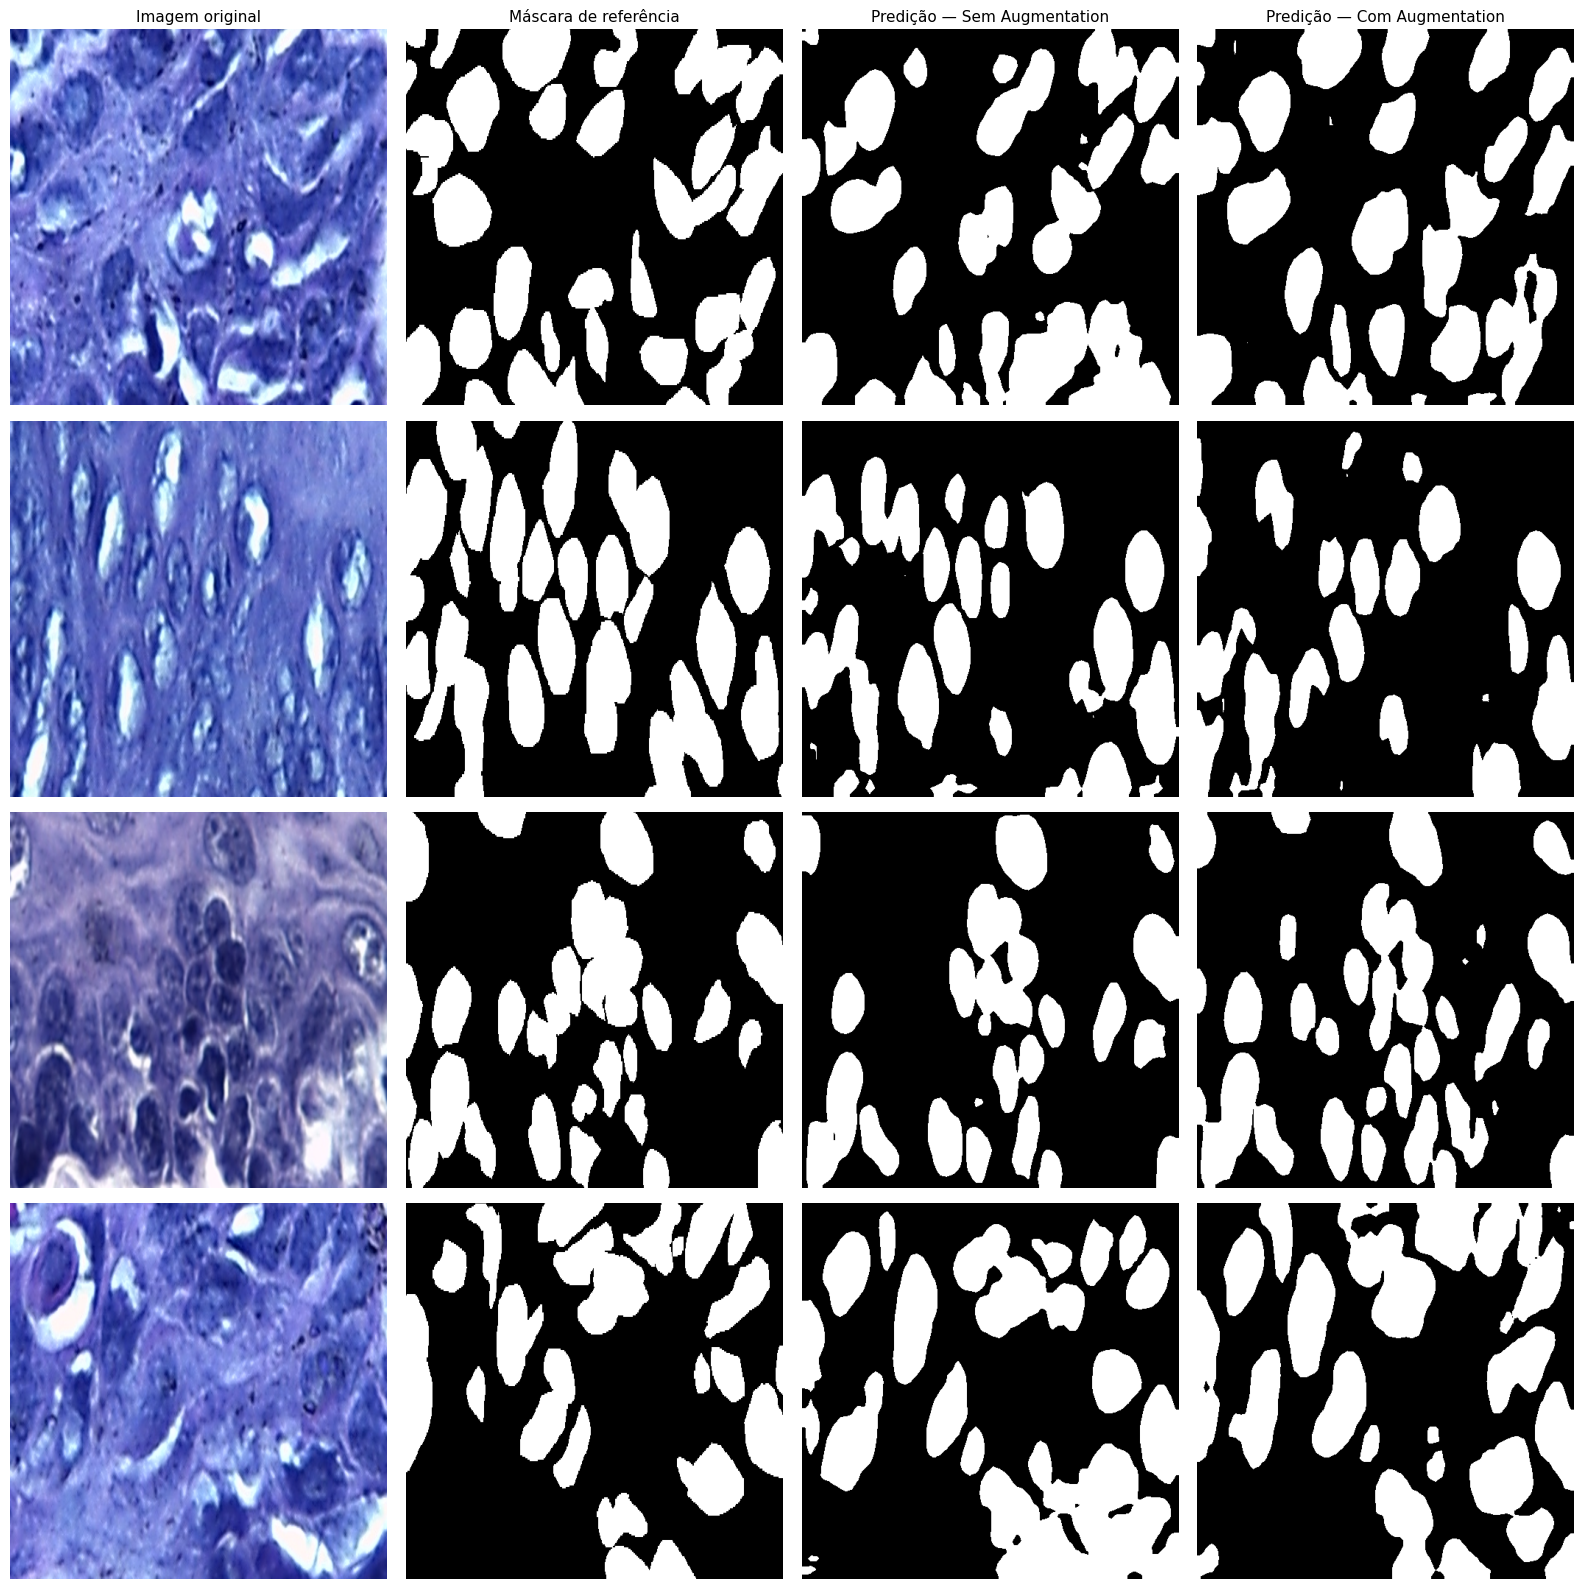

In [19]:
def load_image_rgb(path):
    img = Image.open(path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img.resize((512, 512), Image.BILINEAR)

n_examples = min(4, len(test_idx))
example_idx = test_idx[:n_examples]

fig, axes = plt.subplots(n_examples, 4, figsize=(16, 4 * n_examples))
if n_examples == 1:
    axes = axes[None, :]

col_titles = ['Imagem original', 'Máscara de referência', 'Predição — Sem Augmentation', 'Predição — Com Augmentation']

for row, idx in enumerate(example_idx):
    fname = dataset_base.filename(idx)
    image = load_image_rgb(dataset_base.images[idx])
    ref_mask = np.array(Image.open(dataset_base.masks[idx]).convert('L').resize((512, 512), Image.NEAREST))
    pred_no_aug = cv2.imread(os.path.join(output_dir_no_aug, f'{fname}.png'), cv2.IMREAD_GRAYSCALE)
    pred_aug = cv2.imread(os.path.join(output_dir_aug, f'{fname}.png'), cv2.IMREAD_GRAYSCALE)

    for col, img_data in enumerate([image, ref_mask, pred_no_aug, pred_aug]):
        cmap = None if col == 0 else 'gray'
        axes[row, col].imshow(img_data, cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(comparativo_dir, 'comparativo_visual_mascaras.png'), dpi=150)
plt.show()


### 9.4 Conclusão automática

In [20]:
melhor_dice = 'Com Augmentation' if history_aug['dice'][-1] > history_no_aug['dice'][-1] else 'Sem Augmentation'
melhor_iou = 'Com Augmentation' if history_aug['iou'][-1] > history_no_aug['iou'][-1] else 'Sem Augmentation'

print("=" * 60)
print("RESUMO COMPARATIVO — FCN ResNet50 (fundo x núcleo)")
print("=" * 60)
print(f"Função de perda : {LOSS_NAME}")
print(f"Otimizador      : {OPTIMIZER_NAME}")
print(f"Taxa de aprend. : {LEARNING_RATE}")
print(f"Épocas          : {NUM_EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")
print("-" * 60)
print(f"Sem Augmentation -> Acc: {history_no_aug['pixel_acc'][-1]:.4f} | "
      f"Dice: {history_no_aug['dice'][-1]:.4f} | IoU: {history_no_aug['iou'][-1]:.4f}")
print(f"Com Augmentation -> Acc: {history_aug['pixel_acc'][-1]:.4f} | "
      f"Dice: {history_aug['dice'][-1]:.4f} | IoU: {history_aug['iou'][-1]:.4f}")
print("-" * 60)
print(f"Melhor Dice: {melhor_dice}")
print(f"Melhor IoU : {melhor_iou}")
print("=" * 60)
print(f"\nArquivos salvos em: {comparativo_dir}")
print(" - comparativo_metricas.csv")
print(" - comparativo_curvas.png")
print(" - comparativo_visual_mascaras.png")
print(f" - máscaras preditas em fcn_masks/sem_augmentation/ e fcn_masks/com_augmentation/")


RESUMO COMPARATIVO — FCN ResNet50 (fundo x núcleo)
Função de perda : CrossEntropyLoss
Otimizador      : Adam
Taxa de aprend. : 0.001
Épocas          : 10
Batch size      : 10
------------------------------------------------------------
Sem Augmentation -> Acc: 0.8575 | Dice: 0.7175 | IoU: 0.5655
Com Augmentation -> Acc: 0.8737 | Dice: 0.7616 | IoU: 0.6227
------------------------------------------------------------
Melhor Dice: Com Augmentation
Melhor IoU : Com Augmentation

Arquivos salvos em: /content/drive/MyDrive/LIPAI/S19/fcn_masks
 - comparativo_metricas.csv
 - comparativo_curvas.png
 - comparativo_visual_mascaras.png
 - máscaras preditas em fcn_masks/sem_augmentation/ e fcn_masks/com_augmentation/
